# Feature Engineering — Text Summarization System

**Step 2 of the NLP Pipeline**

This notebook builds on the preprocessed data (`preprocessed_train_fast.csv`) and performs:

| # | Task | Method |
|---|------|--------|
| 1 | **TF-IDF Features** | `TfidfVectorizer` → sentence scores |
| 2 | **Word2Vec Embeddings** | Train on corpus → sentence vectors |
| 3 | **Sentence Importance Score** | Combine TF-IDF + embedding similarity |
| 4 | **Save Features** | Persist for use in downstream summarization steps |

## 0 — Imports & Configuration

In [ ]:
import warnings, os, ast
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from gensim.models import Word2Vec

# directories 
DATA_DIR   = ''
OUTPUT_DIR = 'features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅  All imports OK')
print(f'   Data directory   : {os.path.abspath(DATA_DIR)}')
print(f'   Feature directory: {os.path.abspath(OUTPUT_DIR)}')

✅  All imports OK
   Data directory   : e:\FCAI\y4 sem2\NLP\Text-Summerization-System
   Feature directory: e:\FCAI\y4 sem2\NLP\Text-Summerization-System\features


## 1 — Load Preprocessed Data

In [ ]:
df = pd.read_csv(os.path.join(DATA_DIR, 'preprocessed_train_fast.csv'))

# parse 'sentences' column (stored as string repr of list) 
def safe_parse_list(val):
    if isinstance(val, list):  return val
    try:                        return ast.literal_eval(val)
    except Exception:           return []

df['sentences'] = df['sentences'].apply(safe_parse_list)

# drop rows with empty sentences or clean_text 
df = df[df['sentences'].map(len) > 0].reset_index(drop=True)
df = df[df['clean_text'].notna() & (df['clean_text'].str.strip() != '')].reset_index(drop=True)

print(f'Rows loaded : {len(df):,}')
print(f'Columns     : {list(df.columns)}')
df[['article', 'clean_text', 'sentences']].head(2)

Rows loaded : 5,000
Columns     : ['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text']


,article,clean_text,sentences
0,"Former Sen. Rick Santorum, R-Pennsylvania, sai...",former sen rick santorum rpennsylvania said we...,"[Rick Santorum, R-Pennsylvania, said this week..."
1,David Cameron and Theresa May are locked in a ...,david cameron theresa may locked battle curb p...,[David Cameron and Theresa May are locked in a...


## 2 — Feature Extraction: TF-IDF

### 2.1  Corpus-level TF-IDF vocabulary
We fit a `TfidfVectorizer` on the full corpus of **cleaned texts**.  
This learns which words are **rare across articles** (high IDF) and therefore carry strong signal.

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20_000,   # keep top 20k vocabulary terms
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # apply log(1 + tf) smoothing
    min_df=2               # ignore terms appearing in < 2 docs
)

# Fit on cleaned text corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'TF-IDF matrix   : {tfidf_matrix.shape}  (docs × terms)')

Vocabulary size : 20,000
TF-IDF matrix   : (5000, 20000)  (docs × terms)


### 2.2  Sentence-level TF-IDF score

For each article we:
1. Split into individual sentences (already done in preprocessing).
2. Vectorize each sentence using the fitted vocabulary.
3. Compute the **mean TF-IDF weight** of the sentence as its importance score.

Higher score → sentence contains more distinctive / important keywords.

In [7]:
def score_sentences_tfidf(sentences, vectorizer):
    """
    Returns a list of TF-IDF importance scores, one per sentence.
    Score = mean of non-zero TF-IDF weights in that sentence.
    """
    if not sentences:
        return []
    
    # preprocess sentences the same way (lowercase, no punct)
    import re
    clean = [re.sub(r'[^a-zA-Z\s]', '', s.lower()) for s in sentences]
    
    try:
        mat = vectorizer.transform(clean)          # shape: (n_sents, vocab)
    except Exception:
        return [0.0] * len(sentences)
    
    # mean of non-zero entries per row
    scores = []
    for i in range(mat.shape[0]):
        row = mat.getrow(i)
        nz  = row.data
        scores.append(float(nz.mean()) if len(nz) > 0 else 0.0)
    
    return scores

# Apply to every article
from tqdm import tqdm
tqdm.pandas(desc='TF-IDF sentence scoring')

df['tfidf_scores'] = df['sentences'].progress_apply(
    lambda sents: score_sentences_tfidf(sents, tfidf_vectorizer)
)

# Sanity check on one article
idx = 0
print('\n── Sample article sentence scores ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['tfidf_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

TF-IDF sentence scoring: 100%|██████████| 5000/5000 [00:29<00:00, 171.66it/s]


── Sample article sentence scores ──
  [0.1901]  Rick Santorum, R-Pennsylvania, said this week that the growing threat towards Am
  [0.1715]  Arguing that the rise of the Nazi regime happened in a stable country where it w
  [0.2806]  "Germany, prior to the Nazis getting there, was a very religious country," Santo
  [0.6692]  It was a very sophisticated country
  [0.2003]  " "The idea that you can have this kind of persecution take place over a period 


### 2.3  Visualise TF-IDF score distribution

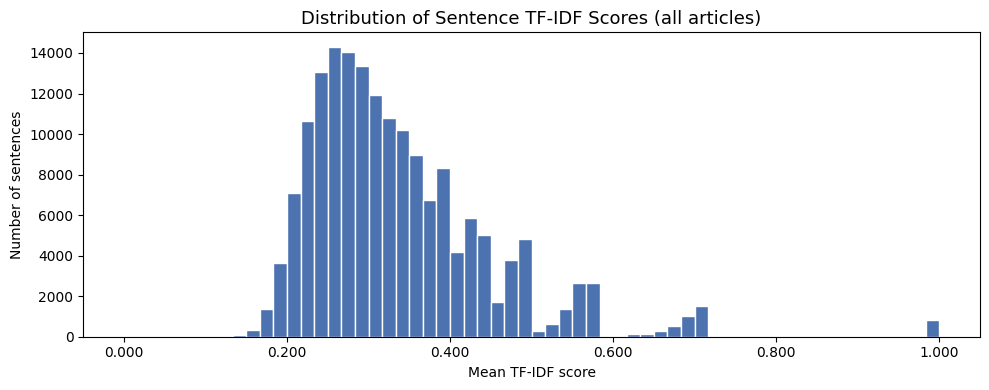

Score stats →  mean=0.3368  median=0.3109  max=1.0000


In [8]:
all_scores = [sc for row in df['tfidf_scores'] for sc in row]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=60, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Sentence TF-IDF Scores (all articles)', fontsize=13)
ax.set_xlabel('Mean TF-IDF score')
ax.set_ylabel('Number of sentences')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tfidf_score_distribution.png'), dpi=120)
plt.show()

print(f'Score stats →  mean={np.mean(all_scores):.4f}  '
      f'median={np.median(all_scores):.4f}  '
      f'max={np.max(all_scores):.4f}')

## 3 — Feature Extraction: Word2Vec Embeddings

### 3.1  Train Word2Vec on the corpus

We train a **Skip-gram Word2Vec** model on the tokenised texts.  
Each word gets a dense 100-dimensional vector that encodes **semantic meaning**.

In [9]:
# Build list of token lists from clean_text column
from nltk.tokenize import word_tokenize

print('Tokenising corpus for Word2Vec training …')
token_corpus = [text.split() for text in df['clean_text'] if isinstance(text, str)]

print(f'  Documents : {len(token_corpus):,}')
print(f'  Avg tokens: {np.mean([len(t) for t in token_corpus]):.1f}')

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=token_corpus,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=3,       # ignore words appearing < 3 times
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=5,
    seed=42
)

print(f'\n✅  Word2Vec trained')
print(f'   Vocabulary size : {len(w2v_model.wv):,} words')
print(f'   Embedding dims  : {w2v_model.vector_size}')

Tokenising corpus for Word2Vec training …
  Documents : 5,000
  Avg tokens: 378.9

✅  Word2Vec trained
   Vocabulary size : 37,651 words
   Embedding dims  : 100


### 3.2  Inspect the word vector space

A quick sanity-check — semantically similar words should appear close to each other.

In [10]:
probe_words = ['government', 'police', 'economy', 'president', 'report']

print('── Most similar words (Word2Vec) ──\n')
for word in probe_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w} ({s:.2f})" for w, s in similar])
        print(f'  {word:>12} → {similar_str}')
    else:
        print(f'  {word:>12} → (not in vocabulary)')

── Most similar words (Word2Vec) ──

    government → governments (0.76), oppose (0.73), almaliki (0.73), sovereignty (0.72), legitimacy (0.72)
        police → officers (0.83), detectives (0.75), officer (0.65), nypd (0.64), detective (0.63)
       economy → recession (0.84), economic (0.80), downturn (0.80), growth (0.80), gdp (0.79)
     president → obama (0.78), barack (0.76), obamas (0.71), presidents (0.71), hollande (0.69)
        report → contributed (0.65), cnns (0.62), hada (0.62), messia (0.62), abedine (0.60)


### 3.3  Sentence embeddings via mean-pooling

We represent each sentence as the **average Word2Vec vector** of its words.  
Words not in the vocabulary are skipped.

In [11]:
def sentence_to_vector(sentence: str, model: Word2Vec) -> np.ndarray:
    """
    Mean-pool Word2Vec vectors for all known words in the sentence.
    Returns a zero vector if no words are in the vocabulary.
    """
    import re
    tokens = re.sub(r'[^a-zA-Z\s]', '', sentence.lower()).split()
    vecs   = [model.wv[w] for w in tokens if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)          # shape: (vector_size,)
    return np.zeros(model.vector_size)


def get_sentence_embeddings(sentences, model):
    """Return a list of embedding vectors, one per sentence."""
    return [sentence_to_vector(s, model) for s in sentences]


# Apply — store as list of numpy arrays per document
tqdm.pandas(desc='Word2Vec sentence embeddings')

df['sentence_embeddings'] = df['sentences'].progress_apply(
    lambda sents: get_sentence_embeddings(sents, w2v_model)
)

# Show embedding for the first sentence of the first article
emb_sample = df['sentence_embeddings'].iloc[0][0]
print(f'Embedding shape : {emb_sample.shape}')
print(f'Sample values   : {emb_sample[:8].round(4)}')

Word2Vec sentence embeddings: 100%|██████████| 5000/5000 [00:10<00:00, 496.02it/s]

Embedding shape : (100,)
Sample values   : [ 0.037  -0.1411 -0.2016  0.1439 -0.1646  0.3317  0.0174  0.2725]


### 3.4  Centroid similarity score

We compute the **document centroid** (mean of all sentence embeddings) and score each sentence by its **cosine similarity** to that centroid.  
Sentences that are *most representative* of the overall document get higher scores.

In [12]:
def centroid_similarity_scores(sentence_embeddings):
    """
    Compute cosine similarity of each sentence embedding to the document centroid.
    """
    if not sentence_embeddings:
        return []
    
    matrix   = np.vstack(sentence_embeddings)           # (n_sents, dim)
    centroid = matrix.mean(axis=0, keepdims=True)       # (1, dim)
    
    sims = cosine_similarity(matrix, centroid).flatten()  # (n_sents,)
    return sims.tolist()


tqdm.pandas(desc='Centroid similarity scoring')

df['embedding_scores'] = df['sentence_embeddings'].progress_apply(
    centroid_similarity_scores
)

# Sanity check
idx = 1
print('\n── Centroid similarity scores (sample) ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['embedding_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

Centroid similarity scoring: 100%|██████████| 5000/5000 [00:02<00:00, 1869.73it/s]


── Centroid similarity scores (sample) ──
  [0.9116]  David Cameron and Theresa May are locked in a battle to curb police stop and sea
  [0.9042]  The Prime Minister and Home Secretary are split over plans to limit the use of t
  [0.9528]  Mrs May has warned the excessive use of stop and search is a ‘dreadful waste of 
  [0.9460]  Clash: David Cameron fears Theresa May's plans to rein in the use of stop and se
  [0.8957]  In a damning report last year, Her Majesty’s Chief Inspector of Constabulary fou


## 4 — Combined Sentence Importance Score

We merge the two signals into a single **importance score** per sentence:

$$\text{importance}(s_i) = \alpha \cdot \text{TF-IDF}(s_i) + (1-\alpha) \cdot \text{EmbeddingSim}(s_i)$$

- **TF-IDF score** → sentence contains key distinctive terms  
- **Embedding similarity** → sentence is representative of the document's topic

We normalise both signals to [0, 1] before combining.

In [13]:
ALPHA = 0.5   # weight for TF-IDF; (1-ALPHA) goes to embedding similarity

def normalize(scores):
    """Min-max normalise a list of scores to [0, 1]."""
    arr = np.array(scores, dtype=float)
    rng = arr.max() - arr.min()
    if rng == 0:
        return np.zeros_like(arr).tolist()
    return ((arr - arr.min()) / rng).tolist()


def combined_importance(tfidf_scores, embedding_scores, alpha=ALPHA):
    """
    Weighted combination of normalised TF-IDF and embedding-centroid scores.
    """
    n = len(tfidf_scores)
    if n == 0:
        return []
    
    t_norm = normalize(tfidf_scores)
    e_norm = normalize(embedding_scores) if embedding_scores else [0.0] * n
    
    return [alpha * t + (1 - alpha) * e
            for t, e in zip(t_norm, e_norm)]


df['importance_scores'] = df.apply(
    lambda row: combined_importance(row['tfidf_scores'], row['embedding_scores']),
    axis=1
)

print('✅  Combined importance scores computed')
print(f'   Alpha (TF-IDF weight)          : {ALPHA}')
print(f'   (1-Alpha) (Embedding weight)   : {1 - ALPHA}')

✅  Combined importance scores computed
   Alpha (TF-IDF weight)          : 0.5
   (1-Alpha) (Embedding weight)   : 0.5


## 5 — Demonstration: Top-scored Sentences per Article

Let's visually verify that our scoring picks **informative, high-value sentences**.

In [14]:
def get_top_sentences(sentences, importance_scores, top_n=3):
    """
    Return the top-N sentences by importance score,
    preserving their original document order.
    """
    if not sentences:
        return []
    
    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]
    
    # restore original order
    chosen_idx = sorted([i for i, _ in ranked])
    return [sentences[i] for i in chosen_idx]


for sample_idx in [0, 1, 2]:
    sents  = df['sentences'].iloc[sample_idx]
    scores = df['importance_scores'].iloc[sample_idx]
    top3   = get_top_sentences(sents, scores, top_n=3)
    
    print(f'\n{'='*70}')
    print(f'Article {sample_idx} | {len(sents)} sentences total')
    print(f'{'─'*70}')
    print('Original (first 200 chars):')
    print(' ', str(df['article'].iloc[sample_idx])[:200])
    print('\nTop-3 important sentences (feature-scored):')
    for i, s in enumerate(top3, 1):
        print(f'  [{i}] {s}')


Article 0 | 16 sentences total
──────────────────────────────────────────────────────────────────────
Original (first 200 chars):
  Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing threat towards American religious freedom by the government could lead to "Christian persecution," similar to how the oppress

Top-3 important sentences (feature-scored):
  [1] " "It starts in a gradual erosion," Santorum said
  [2] Asked why such attacks on religious liberties exist in America, Santorum said it is mostly a result of government overreach
  [3] "You either conform to what the government says you have to believe in, or you're going to lose certain privileges

Article 1 | 26 sentences total
──────────────────────────────────────────────────────────────────────
Original (first 200 chars):
  David Cameron and Theresa May are locked in a battle to curb police stop and search powers. The Prime Minister and Home Secretary are split over plans to limit the use of the powers

## 6 — Per-Sentence Feature Table

Build an **exploded** sentence-level DataFrame for detailed inspection and downstream use.

In [15]:
rows = []
for doc_id, row in df.iterrows():
    for rank, (sent, tsc, esc, isc) in enumerate(
        zip(row['sentences'],
            row['tfidf_scores'],
            row['embedding_scores'],
            row['importance_scores'])):
        rows.append({
            'doc_id'          : doc_id,
            'sentence_rank'   : rank,
            'sentence'        : sent,
            'tfidf_score'     : round(tsc,  5),
            'embedding_score' : round(esc,  5),
            'importance_score': round(isc,  5),
        })

sent_df = pd.DataFrame(rows)
print(f'Sentence table shape: {sent_df.shape}')
sent_df.head(8)

Sentence table shape: (172237, 6)


,doc_id,sentence_rank,sentence,tfidf_score,embedding_score,importance_score
0,0,0,"Rick Santorum, R-Pennsylvania, said this week ...",0.19013,0.93983,0.49124
1,0,1,Arguing that the rise of the Nazi regime happe...,0.17146,0.93972,0.47208
2,0,2,"""Germany, prior to the Nazis getting there, wa...",0.28055,0.92176,0.52120
3,0,3,It was a very sophisticated country,0.66921,0.79952,0.50000
4,0,4,""" ""The idea that you can have this kind of per...",0.20035,0.94306,0.51235
5,0,5,"""It was unfathomable to them that (in) a count...",0.39849,0.86355,0.44366
6,0,6,""" While the former presidential candidate did ...",0.20533,0.94801,0.53403
7,0,7,""" ""It starts in a gradual erosion,"" Santorum said",0.44862,0.92131,0.68851


## 7 — Score Correlation Analysis

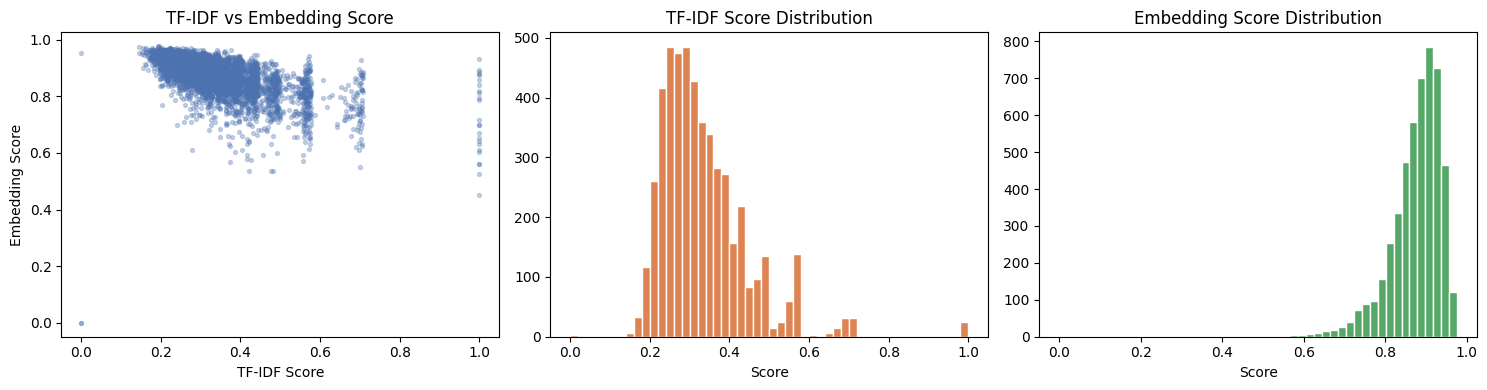


Correlation matrix:
                  tfidf_score  embedding_score  importance_score
tfidf_score             1.000           -0.596             0.304
embedding_score        -0.596            1.000             0.360
importance_score        0.304            0.360             1.000


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample for speed
sample = sent_df.sample(min(5000, len(sent_df)), random_state=42)

axes[0].scatter(sample['tfidf_score'], sample['embedding_score'],
                alpha=0.3, s=8, color='#4C72B0')
axes[0].set_xlabel('TF-IDF Score');  axes[0].set_ylabel('Embedding Score')
axes[0].set_title('TF-IDF vs Embedding Score')

axes[1].hist(sample['tfidf_score'],     bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('TF-IDF Score Distribution');  axes[1].set_xlabel('Score')

axes[2].hist(sample['embedding_score'], bins=50, color='#55A868', edgecolor='white')
axes[2].set_title('Embedding Score Distribution');  axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_score_analysis.png'), dpi=120)
plt.show()

corr = sample[['tfidf_score', 'embedding_score', 'importance_score']].corr()
print('\nCorrelation matrix:')
print(corr.round(3))

## 8 — Save Features

In [ ]:
import pickle, json

# 8a. Document-level features (with lists) → pickle 
doc_features = df[['article', 'highlights', 'clean_text',
                    'sentences', 'tfidf_scores',
                    'embedding_scores', 'importance_scores']].copy()

doc_features.to_pickle(os.path.join(OUTPUT_DIR, 'doc_features.pkl'))
print('✅  Saved  →  features/doc_features.pkl')

# 8b. Sentence-level feature table → CSV
sent_df.to_csv(os.path.join(OUTPUT_DIR, 'sentence_features.csv'), index=False)
print('✅  Saved  →  features/sentence_features.csv')

# 8c. TF-IDF vectorizer → pickle
with open(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('✅  Saved  →  features/tfidf_vectorizer.pkl')

# 8d. Word2Vec model 
w2v_model.save(os.path.join(OUTPUT_DIR, 'word2vec.model'))
print('✅  Saved  →  features/word2vec.model')

# 8e. Config metadata
config = {
    'alpha'            : ALPHA,
    'tfidf_max_features': 20_000,
    'tfidf_ngram_range': [1, 2],
    'w2v_vector_size'  : w2v_model.vector_size,
    'w2v_window'       : 5,
    'w2v_min_count'    : 3,
    'w2v_sg'           : 1,
    'docs_processed'   : len(df)
}
with open(os.path.join(OUTPUT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('✅  Saved  →  features/feature_config.json')

✅  Saved  →  features/doc_features.pkl
✅  Saved  →  features/sentence_features.csv
✅  Saved  →  features/tfidf_vectorizer.pkl
✅  Saved  →  features/word2vec.model
✅  Saved  →  features/feature_config.json


## 9 — Summary

| Feature | Description | Saved as |
|---------|-------------|----------|
| **TF-IDF matrix** | Corpus-level term weights (20k vocab, 1–2 grams) | `tfidf_vectorizer.pkl` |
| **TF-IDF sentence score** | Mean TF-IDF weight per sentence | inside `doc_features.pkl` |
| **Word2Vec embeddings** | 100-dim skip-gram trained on corpus | `word2vec.model` |
| **Embedding similarity** | Cosine similarity to document centroid | inside `doc_features.pkl` |
| **Combined importance** | α·TF-IDF + (1-α)·EmbSim, both normalised | `doc_features.pkl` & `sentence_features.csv` |
